### Create Gaussian Process around dataset

In [1]:

from agent.components.GaussianProcess import get_empirical_variable_bounds
from agent.components.RASK import get_dependent_variable_mapping

%load_ext autoreload
%autoreload 2

import pandas as pd

from matplotlib import pyplot as plt
from agent.components.SLORegistry_v2 import calculate_weighted_SLO_F
from agent.components import RASK

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar

from agent.components.commons import SloSet

# s_type = ServiceType.QR
df_explore = pd.read_csv("../statics/agent_experience/metrics_ICSOC_EXPLORE.csv")
df_explore_preprocessed = RASK.preprocess_data(df_explore)

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. Load and Align Data ---
df_candidates = pd.read_csv('../statics/candidates/candidate_solutions_10.csv')
df_physical = RASK.preprocess_data(pd.read_csv('../statics/agent_experience/metrics_ICSOC_candidates.csv'))

if len(df_candidates) != len(df_physical):
    raise RuntimeError(f"Length mismatch! {len(df_candidates)} candidates vs {len(df_physical)} physical rows.")


empirical_variable_bounds = {s: get_empirical_variable_bounds(df_explore_preprocessed)[s] for s in services}

# --- 2. Calculate Actual Fitness for every aligned row ---
def get_actual_fitness(index):
    cand_row = df_candidates.iloc[index]
    phys_row = df_physical.iloc[index]

    s_type = ServiceType(cand_row['service_type'])

    # Build the state based on what REALLY happened physically
    state = {
        ServiceVar.COST: phys_row['cores'],
        ServiceVar.QUALITY: cand_row['data_quality'], # or extract from s_config if needed
        ServiceVar.PERFORMANCE: phys_row['max_tp']
    }

    if s_type == ServiceType.CV:
        state[ServiceVar.MODEL] = cand_row['model_size']

    # Get the SLO criteria used for this candidate
    slos = SloSet[cand_row['slo_set']].value

    # Return the 'Ground Truth' fulfillment score
    return calculate_weighted_SLO_F(state, slos, empirical_variable_bounds[s_type])

# Map the indices to calculate actual fitness
df_candidates['actual_fitness'] = [get_actual_fitness(i) for i in range(len(df_candidates))]

# --- 3. Compute Bagged RMSE per Service/DataRate ---
results = []
# This groups the 5 reps and any different SLO sets into one RMSE "bag"
grouped = df_candidates.groupby(['service_type', 'data_rate'])

for (s_name, rate), sample_group in grouped:
    # RMSE comparing predicted vs actual fulfillment
    rmse = np.sqrt(mean_squared_error(sample_group['actual_fitness'], sample_group['p_fitness']))

    results.append({
        'service': s_name,
        'data_rate': rate,
        'rmse': rmse,
        'samples': len(sample_group),
        'fitness': np.mean(sample_group['actual_fitness'])
    })

# --- 4. Output results ---
df_final = pd.DataFrame(results)
# pivot_view = df_final.pivot(index='data_rate', columns='service', values=['rmse'])
#
# print("\nRMSE (Predicted vs Physical SLO Fulfillment):")
# print(pivot_view)
# df_final.to_csv('final_slo_fulfillment_rmse.csv', index=False)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


Learning curve plot saved as learning_curve_analysis.png


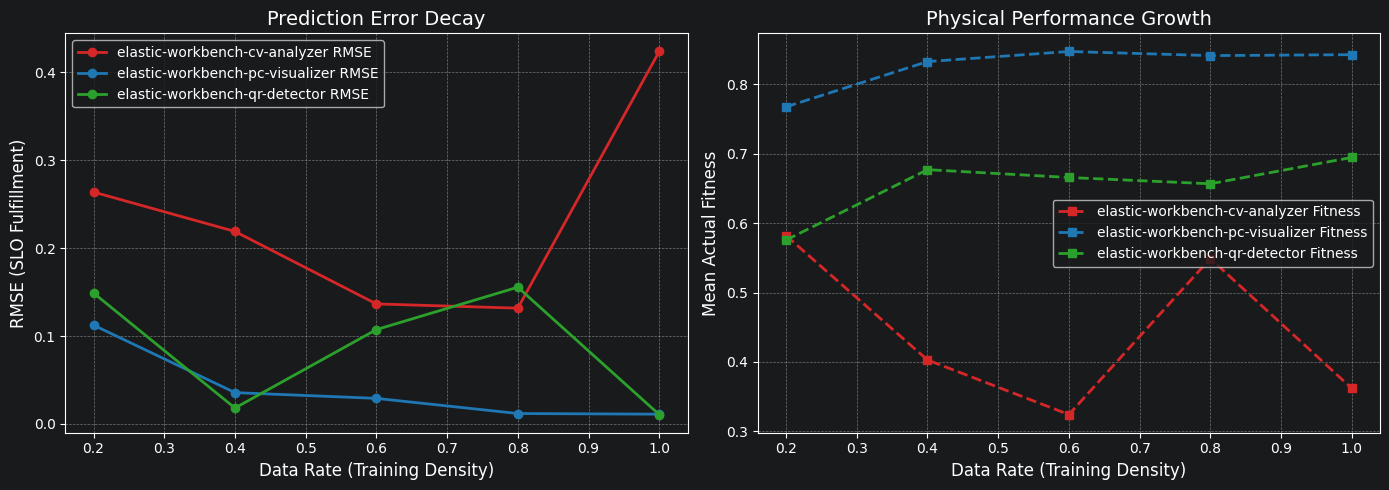

In [3]:

import matplotlib.pyplot as plt

# ... (Previous code for calculating df_final stays the same) ...

# --- 4. Plotting the Learning Curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Identify unique services to plot different lines
services_to_plot = df_final['service'].unique()
# Standard color palette
colors = ['#d62728', '#1f77b4', '#2ca02c'] # Red, Blue, Green

for i, service in enumerate(services_to_plot):
    service_data = df_final[df_final['service'] == service].sort_values('data_rate')

    # 1. RMSE Plot (Lower is better)
    ax1.plot(service_data['data_rate'], service_data['rmse'],
             marker='o', linewidth=2, label=f"{service} RMSE", color=colors[i % len(colors)])

    # 2. Fitness Plot (Higher is better)
    ax2.plot(service_data['data_rate'], service_data['fitness'],
             marker='s', linestyle='--', linewidth=2, label=f"{service} Fitness", color=colors[i % len(colors)])

# Formatting the RMSE chart
ax1.set_title('Prediction Error Decay', fontsize=14)
ax1.set_xlabel('Data Rate (Training Density)', fontsize=12)
ax1.set_ylabel('RMSE (SLO Fulfillment)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Formatting the Fitness chart
ax2.set_title('Physical Performance Growth', fontsize=14)
ax2.set_xlabel('Data Rate (Training Density)', fontsize=12)
ax2.set_ylabel('Mean Actual Fitness', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('learning_curve_analysis.png')
print("Learning curve plot saved as learning_curve_analysis.png")

Relative error comparison plot saved.


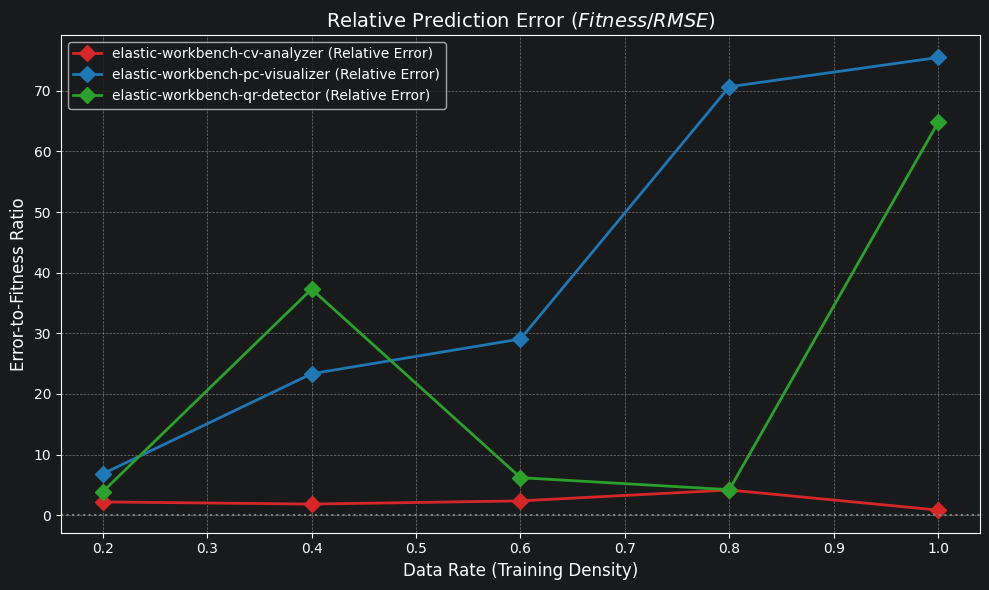

In [4]:
import matplotlib.pyplot as plt

# ... (Previous code for calculating df_final with 'rmse' and 'fitness') ...

# --- 4. Calculate the Relative Error Ratio ---
df_final['error_fitness_ratio'] = df_final['fitness'] / df_final['rmse']

# --- 5. Plotting the Relative Error Comparison ---
plt.figure(figsize=(10, 6))

services_to_plot = df_final['service'].unique()
colors = ['#d62728', '#1f77b4', '#2ca02c']

for i, service in enumerate(services_to_plot):
    service_data = df_final[df_final['service'] == service].sort_values('data_rate')

    plt.plot(service_data['data_rate'], service_data['error_fitness_ratio'],
             marker='D', linewidth=2, markersize=8,
             label=f"{service} (Relative Error)", color=colors[i % len(colors)])

plt.title('Relative Prediction Error ($Fitness / RMSE$)', fontsize=14)
plt.xlabel('Data Rate (Training Density)', fontsize=12)
plt.ylabel('Error-to-Fitness Ratio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Adding a horizontal line at 10% or 20% for benchmark reference
plt.axhline(y=0.1, color='gray', linestyle=':', label='10% Error Threshold')

plt.tight_layout()
plt.savefig('error_fitness_ratio_comparison.png')
print("Relative error comparison plot saved.")